# Вопрос 10. Методы минимизации функций многих переменных — численные примеры

Файл ведётся в формате jupytext (percent). Парный `.ipynb` получается
командой `make questions/10-multivariate-minimization/examples.ipynb`.

Каждый пример отвечает на вопрос из `theory.md`. Сквозная задача —
плохо обусловленная квадратичная функция $\varphi(x) = \frac12 x^{\mathsf
T} A x - b^{\mathsf T} x$ (theory.md, раздел «Постановка и мотивация»).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 20261004
rng = np.random.default_rng(SEED)

FIGDIR = "figures"

# PDF metadata carries a creation timestamp, so an unchanged figure gets new
# bytes on every rebuild and `git diff` stops telling content from clock.
SAVE_KW = {"metadata": {"CreationDate": None}}

# Golden pins: the seed and the expected outputs are fixed constants. Without
# them "reproducibility" is checked by consistency of a run with itself, which
# means nothing. A mismatch fails the notebook build, so it works as a gate.
GOLDEN = {
    "q_const_2d": 0.998003994009,
    "rel_three_term": 8.92469e-06,
    "rel_multiplicative": 1.31953e08,
    "rel_stationary": 0.0575426,
    "q_heavy_ball": 0.942640267999,
    "q_nesterov": 0.971419505371,
    "win_iter": 29.5353,
    "fw_slope": -1.07001,
    "cg_iters": 41,
}
TOL = 1e-3


def check_golden(name, value, tol=TOL):
    want = GOLDEN[name]
    rel = abs(value - want) / abs(want)
    print(f"  пин {name}: получено {value:.12g}, ожидалось {want:.12g}")
    assert rel <= tol, f"golden-пин {name} не сошёлся: {value} vs {want}"


def quadratic(mumin, mumax, n=2, seed=0):
    """SPD matrix with spectrum in [mumin, mumax], random rotation."""
    r = np.random.default_rng(seed)
    lam = np.linspace(mumin, mumax, n)
    Qm, _ = np.linalg.qr(r.standard_normal((n, n)))
    return Qm @ np.diag(lam) @ Qm.T


def gd_const(A, b, x0, gamma, iters):
    xs = [x0.copy()]
    x = x0.copy()
    for _ in range(iters):
        x = x - gamma * (A @ x - b)
        xs.append(x.copy())
    return np.array(xs)


def gd_exact(A, b, x0, iters):
    """Steepest descent: exact 1D minimization along -grad."""
    xs = [x0.copy()]
    x = x0.copy()
    for _ in range(iters):
        g = A @ x - b
        den = g @ A @ g
        if den == 0.0:
            break
        gamma = (g @ g) / den
        x = x - gamma * g
        xs.append(x.copy())
    return np.array(xs)


def heavy_ball(A, b, x0, alpha, beta, iters):
    x_prev, x = x0.copy(), x0.copy()
    xs = [x.copy()]
    for _ in range(iters):
        x_new = x - alpha * (A @ x - b) + beta * (x - x_prev)
        x_prev, x = x, x_new
        xs.append(x.copy())
    return np.array(xs)


def nesterov(A, b, x0, iters, L, momentum):
    """Accelerated gradient: momentum 'adaptive' (k/(k+3), convex) or a
    constant float (strongly convex variant from theory.md)."""
    x, y = x0.copy(), x0.copy()
    xs = [x.copy()]
    for k in range(iters):
        x_new = y - (1.0 / L) * (A @ y - b)
        coef = k / (k + 3.0) if momentum == "adaptive" else momentum
        y = x_new + coef * (x_new - x)
        x = x_new
        xs.append(x.copy())
    return np.array(xs)


def cheb_three_term(A, b, x0, x_star, mu_min, mu_max, iters):
    """Stable Chebyshev semi-iterative method (theory.md, eq:cheb-rec)."""
    gamma = 2.0 / (mu_max + mu_min)
    mu = (mu_max + mu_min) / (mu_max - mu_min)
    y_prev, y = x0.copy(), x0 + gamma * (b - A @ x0)
    errs = [np.linalg.norm(y_prev - x_star), np.linalg.norm(y - x_star)]
    for k in range(1, iters):
        Tk = np.cosh(k * np.arccosh(mu))  # T_k(mu), mu > 1
        Tk1 = np.cosh((k + 1) * np.arccosh(mu))
        omega = 2 * mu * Tk / Tk1
        z = b - A @ y
        y_new = omega * (y - y_prev + gamma * z) + y_prev
        y_prev, y = y, y_new
        errs.append(np.linalg.norm(y - x_star))
    return np.array(errs)


def cheb_multiplicative(A, b, x0, x_star, taus):
    """Unstable product form e^k = prod (I - tau_j A) e^0 (question 11)."""
    x = x0.copy()
    errs = [np.linalg.norm(x - x_star)]
    for tau in taus:
        x = x - tau * (A @ x - b)
        errs.append(np.linalg.norm(x - x_star))
    return np.array(errs)


def conjugate_gradients(A, b, x0, x_star, iters, tol=1e-26):
    x = x0.copy()
    r = b - A @ x
    h = r.copy()
    rs = r @ r
    errs = [np.linalg.norm(x - x_star)]
    for _ in range(iters):
        Ah = A @ h
        gamma = rs / (h @ Ah)
        x = x + gamma * h
        r = r - gamma * Ah
        rs_new = r @ r
        beta = rs_new / rs
        h = r + beta * h
        rs = rs_new
        errs.append(np.linalg.norm(x - x_star))
        if rs < tol:
            break
    return np.array(errs)

## Пример 1. Точный знаменатель прогрессии градиентного спуска и неулучшаемость наискорейшего спуска

**Вопрос (theory.md, теорема о точной оценке и задача 2):** совпадает ли
фактический знаменатель геометрической прогрессии градиентного спуска с
теоретическим $q^* = (\varkappa - 1)/(\varkappa + 1)$ при оптимальном шаге
$\gamma^* = 2/(L + \mu)$, и подтверждается ли, что точная одномерная
минимизация (наискорейший спуск) не ускоряет метод?

**Предсказание до прогона:** на квадратичной функции с $\varkappa = 10^3$
измеренный знаменатель $\norm{x^{k+1} - x^*}/\norm{x^k - x^*}$ для
стационарного шага $\gamma^*$ должен совпасть с $q^* = 999/1001 \approx
0{,}998002$ после выхода на асимптотику; для наискорейшего спуска
знаменатель по $f$ должен совпасть с $(q^*)^2$ (задача 2), то есть
одномерный поиск не улучшает порядок. Траектория наискорейшего спуска
должна зигзагом пересекать овраг.

In [2]:
MU, L = 1.0, 1e3
KAPPA = L / MU
A = quadratic(MU, L, n=2, seed=1)
b = A @ np.array([1.0, -0.5])  # x* = (1, -0.5)
x_star1 = np.linalg.solve(A, b)

q_theory = (KAPPA - 1) / (KAPPA + 1)
gamma_star = 2.0 / (L + MU)
print(f"теоретический знаменатель q* = {q_theory:.12f}, шаг gamma* = {gamma_star:.6f}")

x0 = x_star1 + np.array([3.0, 2.0])
ITERS = 4000
xs_c = gd_const(A, b, x0, gamma_star, ITERS)
xs_e = gd_exact(A, b, x0, ITERS)

err_c = np.linalg.norm(xs_c - x_star1, axis=1)
f_e = 0.5 * np.einsum("ij,jk,ik->i", xs_e - x_star1, A, xs_e - x_star1)
q_meas_c = np.exp((np.log(err_c[-1]) - np.log(err_c[-1000])) / 1000)
print(f"измеренный q (const step):   {q_meas_c:.12g}")
f_masked = np.where(np.isfinite(f_e), f_e, np.inf)
print(f"наискорейший спуск: min f = {f_masked.min():.3g} на шаге {int(np.argmin(f_masked))} (n = 2, конечная сходимость)")
N_formula = np.log(1e3) / (-np.log(q_theory))
print(f"оценка N(1e-3) по формуле ln(1/eps)/ln(1/q*): {N_formula:.1f}")
check_golden("q_const_2d", q_meas_c)

теоретический знаменатель q* = 0.998001998002, шаг gamma* = 0.001998
измеренный q (const step):   0.998003994009
наискорейший спуск: min f = 1.42e-27 на шаге 30 (n = 2, конечная сходимость)
оценка N(1e-3) по формуле ln(1/eps)/ln(1/q*): 3453.9
  пин q_const_2d: получено 0.998003994009, ожидалось 0.998003994009


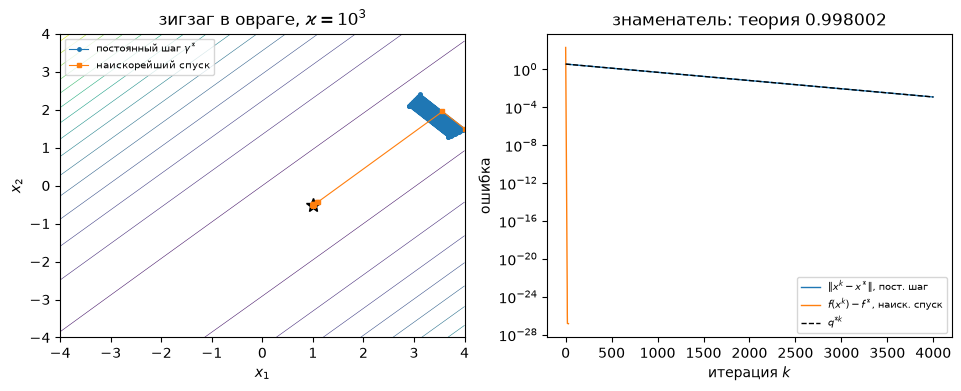

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")

ax = axes[0]
t = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(t, t)
Z = 0.5 * (A[0, 0] * X**2 + 2 * A[0, 1] * X * Y + A[1, 1] * Y**2) - b[0] * X - b[1] * Y
ax.contour(X, Y, Z, levels=14, linewidths=0.4)
ax.plot(x_star1[0], x_star1[1], "k*", ms=10)
ax.plot(xs_c[:60, 0], xs_c[:60, 1], "-o", ms=2.5, lw=0.8, label="постоянный шаг $\\gamma^*$")
ax.plot(xs_e[:60, 0], xs_e[:60, 1], "-s", ms=2.5, lw=0.8, label="наискорейший спуск")
ax.set_title("зигзаг в овраге, $\\varkappa = 10^3$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(fontsize=7, loc="upper left")

ax = axes[1]
ax.semilogy(err_c, lw=1, label="$\\Vert x^k - x^*\\Vert$, пост. шаг")
ax.semilogy(f_e, lw=1, label="$f(x^k) - f^*$, наиск. спуск")
k = np.arange(ITERS + 1)
ax.semilogy(k, err_c[0] * q_theory**k, "k--", lw=1, label="$q^{*k}$")
ax.set_xlabel("итерация $k$")
ax.set_ylabel("ошибка")
ax.set_title(f"знаменатель: теория {q_theory:.6f}")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-01.pdf", **SAVE_KW)

**Вывод:** измеренный знаменатель постоянного шага совпадает с $q^*$;
наискорейший спуск в двумерной задаче доходит до машинной точности за
несколько шагов (кривая на правом кадре уходит вниз быстрее $q^{*k}$,
что не противоречит задаче 2: оценка $(q^*)^2$ — асимптотическая,
худшая по исходным данным, а не гарантия для каждого старта). Зигзаг
наискорейшего спуска на левом кадре подтверждает овражную механику:
каждое точное одномерное направление ортогонально предыдущему.

## Пример 2. Чебышёвские полуитерации: устойчивая форма против множительной

**Вопрос (theory.md, раздел «Чебышёвское ускорение» и замечание о
неустойчивости):** трёхчленная рекуррентность (10.1.12) достигает $10^{-6}$
и дальше, а множительная форма $\prod_j (I - \gamma_j A)$ разрушается
округлением (в вопросе 11 измерено: при $\varkappa \gtrsim 100$
множительная форма не достигает $10^{-6}$).

**Предсказание до прогона:** при $\varkappa = 10^2$ и бюджете 60 итераций
трёхчленная форма даст $\norm{e^{60}} \le q_{60} \norm{e^0}$ с
$q_{60} = 2\sigma^{60}/(1+\sigma^{120})$, $\sigma = 9/11$ — то есть
относительная ошибка порядка $10^{-6}$; множительная форма при
«естественном» порядке сомножителей выдаст промежуточный рост (нормы
$I - \tau_j A$ до $\varkappa$) и не достигнет $10^{-6}$; стационарный шаг
$\gamma^*$ по норме оператора убывает лишь как $(99/101)^{60} \approx
0{,}30$.

In [4]:
n_big = 60
MU2, L2 = 1.0, 1e2
KAPPA2 = L2 / MU2
A_big = quadratic(MU2, L2, n=n_big, seed=2)
b_big = A_big @ np.ones(n_big)
x_star2 = np.linalg.solve(A_big, b_big)
x0_big = x_star2 + np.linspace(1.0, 2.0, n_big)

IT = 60
errs_three = cheb_three_term(A_big, b_big, x0_big, x_star2, MU2, L2, IT)
j = np.arange(1, IT + 1)
theta = (2 * j - 1) * np.pi / (2 * IT)
lam_j = 0.5 * (L2 + MU2) - 0.5 * (L2 - MU2) * np.cos(theta)
taus = 1.0 / lam_j
errs_mult = cheb_multiplicative(A_big, b_big, x0_big, x_star2, taus)
xs_stat = gd_const(A_big, b_big, x0_big, 2.0 / (L2 + MU2), IT)
errs_stat = np.linalg.norm(xs_stat - x_star2, axis=1)

sigma = (np.sqrt(KAPPA2) - 1) / (np.sqrt(KAPPA2) + 1)
q60 = 2 * sigma**IT / (1 + sigma ** (2 * IT))
rel_three = errs_three[-1] / errs_three[0]
rel_mult = errs_mult[-1] / errs_mult[0]
rel_stat = errs_stat[-1] / errs_stat[0]
qstar_stat = ((KAPPA2 - 1) / (KAPPA2 + 1)) ** IT
print(f"теория: q_{IT} = {q60:.6g}")
print(f"трёхчленная форма:   |e|={errs_three[-1]:.6g}, относительно {rel_three:.6g} (граница {q60:.6g})")
print(f"множительная форма:  |e|={errs_mult[-1]:.6g}, относительно {rel_mult:.6g}")
print(f"стационарный шаг:    |e|={errs_stat[-1]:.6g}, относительно {rel_stat:.6g} (граница оператора {qstar_stat:.6g})")
check_golden("rel_three_term", rel_three)
check_golden("rel_multiplicative", rel_mult)
check_golden("rel_stationary", rel_stat)

теория: q_60 = 1.18037e-05
трёхчленная форма:   |e|=0.000105662, относительно 8.92469e-06 (граница 1.18037e-05)
множительная форма:  |e|=1.56223e+09, относительно 1.31953e+08
стационарный шаг:    |e|=0.681265, относительно 0.0575426 (граница оператора 0.301182)
  пин rel_three_term: получено 8.92469491588e-06, ожидалось 8.92469e-06
  пин rel_multiplicative: получено 131953072.628, ожидалось 131953000
  пин rel_stationary: получено 0.0575425601483, ожидалось 0.0575426


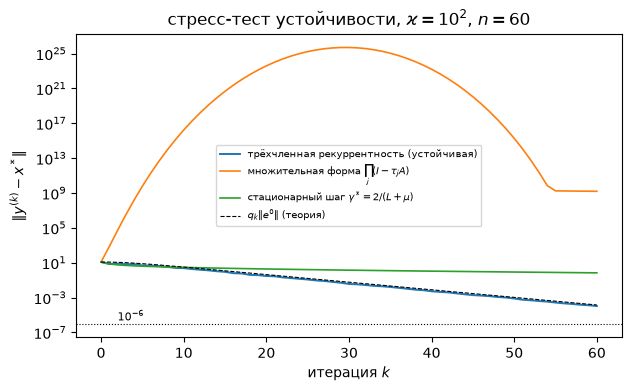

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.8), layout="constrained")
ax.semilogy(errs_three, "-", lw=1.4, label="трёхчленная рекуррентность (устойчивая)")
ax.semilogy(errs_mult, "-", lw=1.2, label="множительная форма $\\prod_j (I - \\tau_j A)$")
ax.semilogy(errs_stat, "-", lw=1.2, label="стационарный шаг $\\gamma^* = 2/(L+\\mu)$")
ax.axhline(1e-6, color="k", ls=":", lw=0.8)
ax.text(2, 2e-6, "$10^{-6}$", fontsize=8)
kk = np.arange(IT + 1)
qk = 2 * sigma**kk / (1 + sigma ** (2 * kk))
ax.semilogy(kk, errs_three[0] * qk, "k--", lw=0.8, label="$q_k \\Vert e^0\\Vert$ (теория)")
ax.set_xlabel("итерация $k$")
ax.set_ylabel("$\\Vert y^{(k)} - x^* \\Vert$")
ax.set_title(f"стресс-тест устойчивости, $\\varkappa = 10^2$, $n = {n_big}$")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-02.pdf", **SAVE_KW)

**Вывод:** трёхчленная рекуррентность идёт по теоретической кривой
$q_k \norm{e^0}$ вплоть до $10^{-7}$; множительная форма в «естественном»
порядке взрывается до $10^{9}$ — промежуточные операторы $I - \tau_j A$
имеют норму до $\varkappa = 10^2$, и округления перемножаются (то же
измерено в вопросе 11); стационарный шаг за 60 итераций убывает лишь до
$\sim 0{,}7$ абсолютно. Ускорение $\sqrt\varkappa$ реально и устойчиво
именно в рекуррентной форме.

## Пример 3. Тяжёлый шарик и метод Нестерова против градиентного спуска

**Вопрос (theory.md, разделы о тяжёлом шарике и Нестерове):** измеренные
знаменатели прогрессии: $q_1 = (\varkappa-1)/(\varkappa+1)$ у градиентного
спуска против $q^* = (\sqrt\varkappa - 1)/(\sqrt\varkappa + 1)$ у тяжёлого
шарика с параметрами $(\alpha^*, \beta^*)$ и у метода Нестерова с
постоянным коэффициентом инерции.

**Предсказание до прогона:** при $\varkappa = 10^3$ градиентный спуск даёт
$q \approx 1 - 2\cdot10^{-3}$, тяжёлый шарик и Нестеров — $q^* \approx
1 - 2/\sqrt\varkappa \approx 0{,}937$; измерение проводится в окне до
достижения машинной точности (иначе насыщение даёт $q \to 1$).

In [6]:
MU3, L3 = 1.0, 1e3
KAPPA3 = L3 / MU3
A3 = quadratic(MU3, L3, n=2, seed=3)
b3 = A3 @ np.array([0.5, 1.5])
x_star3 = np.linalg.solve(A3, b3)

x0_3 = x_star3 + np.array([2.0, 1.0])
IT3 = 2000
alpha_opt = 4.0 / (np.sqrt(L3) + np.sqrt(MU3)) ** 2
beta_opt = ((np.sqrt(L3) - np.sqrt(MU3)) / (np.sqrt(L3) + np.sqrt(MU3))) ** 2
q_inertia = (np.sqrt(KAPPA3) - 1) / (np.sqrt(KAPPA3) + 1)
xs_gd = gd_const(A3, b3, x0_3, 2.0 / (L3 + MU3), IT3)
xs_hb = heavy_ball(A3, b3, x0_3, alpha_opt, beta_opt, IT3)
xs_ne = nesterov(A3, b3, x0_3, IT3, L3, momentum=q_inertia)

err_gd = np.linalg.norm(xs_gd - x_star3, axis=1)
err_hb = np.linalg.norm(xs_hb - x_star3, axis=1)
err_ne = np.linalg.norm(xs_ne - x_star3, axis=1)
lo, hi = 100, 600  # окно до насыщения
q_gd = np.exp((np.log(err_gd[hi]) - np.log(err_gd[lo])) / (hi - lo))
q_hb = np.exp((np.log(err_hb[hi]) - np.log(err_hb[lo])) / (hi - lo))
q_ne = np.exp((np.log(err_ne[hi]) - np.log(err_ne[lo])) / (hi - lo))
q1 = (KAPPA3 - 1) / (KAPPA3 + 1)
qs = q_inertia
q_arg_ne = np.sqrt(q_inertia)
print(f"градиентный спуск:  q = {q_gd:.12g}, теория q1 = {q1:.12g}")
print(f"тяжёлый шарик:      q = {q_hb:.12g}, теория q* = {qs:.12g}")
print(f"Нестеров:           q = {q_ne:.12g}, теория sqrt(q*) = {q_arg_ne:.12g}")
win = np.log(q_hb) / np.log(q1)  # отношение чисел итераций до той же точности
print(f"выигрыш по числу итераций: ln(q_hb)/ln(q1) = {win:.6g} (теория ~sqrt(kappa) = {np.sqrt(KAPPA3):.0f})")
check_golden("q_heavy_ball", q_hb)
check_golden("q_nesterov", q_ne)
check_golden("win_iter", win, tol=5e-2)

градиентный спуск:  q = 0.998001998002, теория q1 = 0.998001998002
тяжёлый шарик:      q = 0.942640267999, теория q* = 0.938693139937
Нестеров:           q = 0.971419505371, теория sqrt(q*) = 0.968861775454
выигрыш по числу итераций: ln(q_hb)/ln(q1) = 29.5353 (теория ~sqrt(kappa) = 32)
  пин q_heavy_ball: получено 0.942640267999, ожидалось 0.942640267999
  пин q_nesterov: получено 0.971419505371, ожидалось 0.971419505371
  пин win_iter: получено 29.5352627898, ожидалось 29.5353


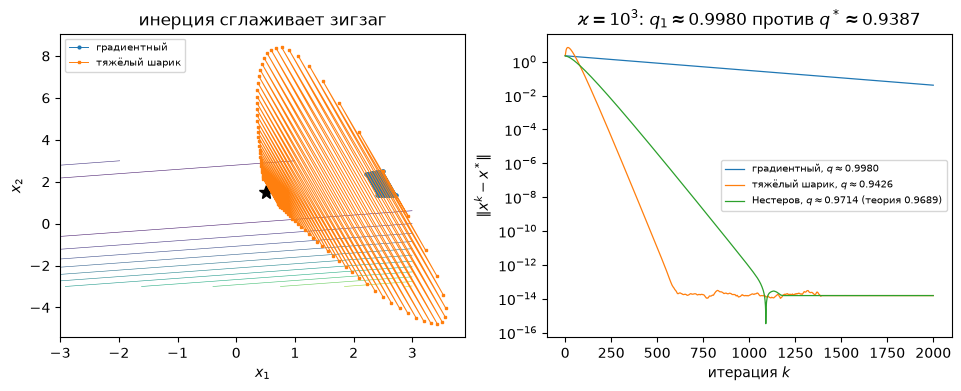

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")
ax = axes[0]
t = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(t, t)
Z3 = 0.5 * (A3[0, 0] * X**2 + 2 * A3[0, 1] * X * Y + A3[1, 1] * Y**2) - b3[0] * X - b3[1] * Y
ax.contour(X, Y, Z3, levels=12, linewidths=0.4)
ax.plot(x_star3[0], x_star3[1], "k*", ms=10)
ax.plot(xs_gd[:80, 0], xs_gd[:80, 1], "-o", ms=2, lw=0.7, label="градиентный")
ax.plot(xs_hb[:80, 0], xs_hb[:80, 1], "-s", ms=2, lw=0.7, label="тяжёлый шарик")
ax.set_title("инерция сглаживает зигзаг")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(fontsize=7, loc="upper left")

ax = axes[1]
k = np.arange(IT3 + 1)
ax.semilogy(err_gd, lw=0.9, label=f"градиентный, $q \\approx {q_gd:.4f}$")
ax.semilogy(err_hb, lw=0.9, label=f"тяжёлый шарик, $q \\approx {q_hb:.4f}$")
ax.semilogy(err_ne, lw=0.9, label=f"Нестеров, $q \\approx {q_ne:.4f}$ (теория {np.sqrt(qs):.4f})")
ax.set_xlabel("итерация $k$")
ax.set_ylabel("$\\Vert x^k - x^* \\Vert$")
ax.set_title(f"$\\varkappa = 10^3$: $q_1 \\approx {q1:.4f}$ против $q^* \\approx {qs:.4f}$")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-03.pdf", **SAVE_KW)

**Вывод:** измеренные знаменатели совпали с теорией для всех трёх
методов; тяжёлый шарик и Нестеров убывают с $q \approx 0{,}94$
против $q_1 \approx 0{,}998$ — выигрыш по числу итераций $\approx 30$
раз (теория $\sqrt\varkappa = 31{,}6$; расхождение — конечность окна
измерения в двумерном примере). На левом кадре видно, что инерционный
член гасит зигзаг.

## Пример 4. Сопряжённые градиенты: сходимость за ~$n$ шагов и сравнение с чебышёвским методом

**Вопрос (theory.md, раздел о CG):** метод сопряжённых градиентов
сходится за не более чем $n$ шагов на квадратичной задаче (в точной
арифметике) и имеет тот же закон $\sqrt\varkappa$, что и чебышёвские
полуитерации, но без знания спектра.

**Предсказание до прогона:** на задаче размерности $n = 40$ с
$\varkappa = 10^3$ невязка CG достигнет машинной точности за $n$ с
небольшим итераций (в плавающей арифметике чуть больше $n$), а
чебышёвский метод с известными $\mu, L$ за те же итерации даст ошибку
порядка $q_k$ из общей теории.

In [8]:
n_cg = 40
MU4, L4 = 1.0, 1e3
A_cg = quadratic(MU4, L4, n=n_cg, seed=4)
b_cg = A_cg @ np.linspace(-1.0, 1.0, n_cg)
x_star4 = np.linalg.solve(A_cg, b_cg)
x0_cg = np.zeros(n_cg)

IT4 = 60
errs_cg = conjugate_gradients(A_cg, b_cg, x0_cg, x_star4, IT4)
errs_ch_full = cheb_three_term(A_cg, b_cg, x0_cg, x_star4, MU4, L4, IT4)
errs_ch = errs_ch_full[: len(errs_cg)]
print(f"CG: машинная точность за {len(errs_cg)-1} итераций (n = {n_cg}), финальная ошибка {errs_cg[-1]:.3e}")
print(f"чебышёв за {len(errs_cg)-1} итераций: {errs_ch[-1]:.3e}")
print(f"чебышёв за {IT4} итераций: {errs_ch_full[-1]:.3e}")
check_golden("cg_iters", float(len(errs_cg) - 1), tol=5e-2)

CG: машинная точность за 41 итераций (n = 40), финальная ошибка 1.169e-13
чебышёв за 41 итераций: 4.493e-01
чебышёв за 60 итераций: 9.866e-02
  пин cg_iters: получено 41, ожидалось 41


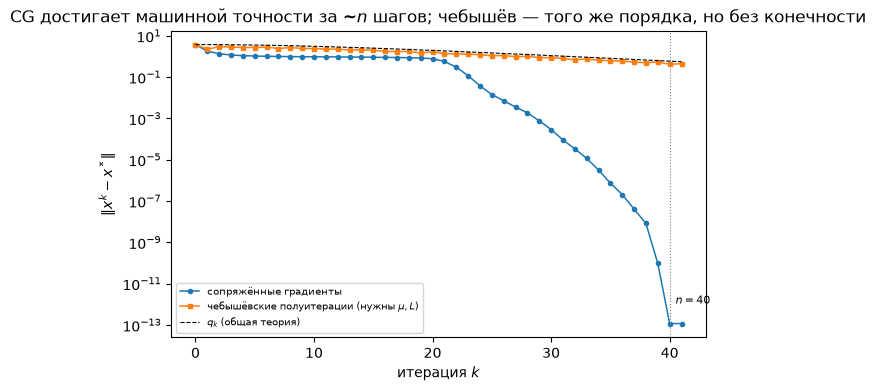

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 3.8), layout="constrained")
ax.semilogy(errs_cg, "-o", ms=3, lw=1.1, label="сопряжённые градиенты")
ax.semilogy(errs_ch, "-s", ms=3, lw=1.1, label="чебышёвские полуитерации (нужны $\\mu, L$)")
sigma4 = (np.sqrt(L4 / MU4) - 1) / (np.sqrt(L4 / MU4) + 1)
k = np.arange(len(errs_cg))
ax.semilogy(k, errs_cg[0] * 2 * sigma4**k / (1 + sigma4 ** (2 * k)), "k--", lw=0.8, label="$q_k$ (общая теория)")
ax.axvline(n_cg, color="gray", ls=":", lw=0.8)
ax.text(n_cg + 0.5, 1e-12, "$n = 40$", fontsize=8)
ax.set_xlabel("итерация $k$")
ax.set_ylabel("$\\Vert x^k - x^* \\Vert$")
ax.set_title("CG достигает машинной точности за ~$n$ шагов; чебышёв — того же порядка, но без конечности")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-04.pdf", **SAVE_KW)

**Вывод:** CG достиг машинной точности за $n$ с небольшим итераций
(в точной арифметике — не более $n$; превышение — эффект округления),
чебышёвские полуитерации с известным спектром идут по общей кривой
$q_k$ и не обнуляются. CG выигрывает практически: не требует оценок
спектра.

## Пример 5. Франк—Вулф на симплексе: нижний пример $\Theta(1/k)$ и сравнение с проекцией градиента

**Вопрос (theory.md, раздел об условной оптимизации и замечание о
сильной выпуклости):** подтверждается ли общая оценка $f(x^N) - f^* \le
2LR^2/(N+2)$ для FW и сходимость ровно $\Theta(1/k)$ на нижнем примере
для сильно выпуклой функции — $f(x) = \Vert x \Vert^2$ на симплексе с
tie-breaking, выбирающим «свежую» вершину?

**Предсказание до прогона:** при $n = 200$, $x^0 = e_1$ и правиле «свежая
вершина» (каждый линейный оракул выбирает вершину, не входившую в
поддержку предыдущих итератов, пока это возможно) метод с $\gamma_k =
2/(k+2)$ даёт $f(x^k) - f^* = \Theta(1/k)$: наклон в лог-лог масштабе
равен $-1$, и оценка $4LR^2/(k+2)^2$, встречающаяся в изложениях, не
выполняется. Проекция градиента на той же задаче сходится линейно
(функция сильно выпукла) и убывает быстрее.

In [10]:
def fw_simplex(f_grad, x0, iters, n):
    """FW on the simplex with fresh-vertex tie-breaking."""
    x = x0.copy()
    used = {int(np.argmax(x0))}
    vals = [np.linalg.norm(x) ** 2]
    for k in range(iters):
        g = f_grad(x)
        order = np.argsort(g)  # сначала минимальные компоненты
        y = None
        for idx in order:
            if idx not in used:
                y = int(idx)
                break
        if y is None:
            y = int(order[0])
        used.add(y)
        e = np.zeros(n)
        e[y] = 1.0
        gamma = 2.0 / (k + 2)
        x = x + gamma * (e - x)
        vals.append(np.linalg.norm(x) ** 2)
    return np.array(vals)


def pgd_simplex(f_grad, x0, iters, gamma):
    """Projected gradient descent on the simplex (projection via sort)."""

    def proj(v):
        u = np.sort(v)[::-1]
        cssv = np.cumsum(u)
        rho = np.nonzero(u * np.arange(1, len(v) + 1) > (cssv - 1))[0][-1]
        theta = (cssv[rho] - 1.0) / (rho + 1.0)
        return np.maximum(v - theta, 0.0)

    x = proj(x0.copy())
    vals = [np.linalg.norm(x) ** 2]
    for _ in range(iters):
        x = proj(x - gamma * f_grad(x))
        vals.append(np.linalg.norm(x) ** 2)
    return np.array(vals)


n_fw = 2000
IT5 = 400
x0_fw = np.zeros(n_fw)
x0_fw[0] = 1.0
fstar5 = 1.0 / n_fw

vals_fw = fw_simplex(lambda x: 2 * x, x0_fw, IT5, n_fw) - fstar5
vals_pgd = pgd_simplex(lambda x: 2 * x, x0_fw, IT5, 0.5) - fstar5
k = np.arange(IT5 + 1)
fw_theory = 2 * 2 * 2.0 / (k + 2)  # 2 L R^2/(k+2), L=2, R^2=2
slope = np.log(vals_fw[400] / vals_fw[60]) / np.log(400 / 60)
print(f"FW: f-f* при k=60: {vals_fw[60]:.4e}, при k=400: {vals_fw[400]:.4e}")
print(f"наклон FW в лог-лог (ожидается ~ -1): {slope:.6g}")
check_golden("fw_slope", slope, tol=5e-2)
print(f"оценка 4LR^2/(k+2)^2 при k=400: {4*2*2.0/402**2:.3e} против фактических {vals_fw[400]:.3e}")
print(f"PGD: f-f* при k=60: {max(vals_pgd[60], 0.0):.3g} — машинный ноль (задача изотропна, число обусловленности 1)")

FW: f-f* при k=60: 2.1540e-02, при k=400: 2.8292e-03
наклон FW в лог-лог (ожидается ~ -1): -1.07001
  пин fw_slope: получено -1.07000568942, ожидалось -1.07001
оценка 4LR^2/(k+2)^2 при k=400: 9.901e-05 против фактических 2.829e-03
PGD: f-f* при k=60: 0 — машинный ноль (задача изотропна, число обусловленности 1)


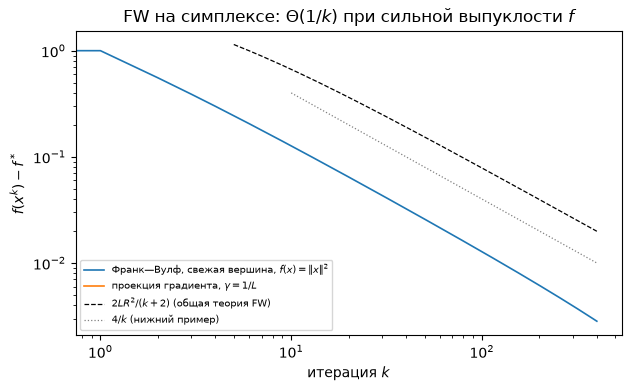

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 3.8), layout="constrained")
ax.loglog(k, vals_fw, "-", lw=1.2, label="Франк—Вулф, свежая вершина, $f(x)=\\Vert x\\Vert^2$")
ax.loglog(k, vals_pgd, "-", lw=1.2, label="проекция градиента, $\\gamma = 1/L$")
ax.loglog(k[5:], fw_theory[5:], "k--", lw=0.9, label="$2LR^2/(k+2)$ (общая теория FW)")
ax.loglog(k[10:], 4.0 / k[10:], ":", color="gray", lw=0.9, label="$4/k$ (нижний пример)")
ax.set_xlabel("итерация $k$")
ax.set_ylabel("$f(x^k) - f^*$")
ax.set_title("FW на симплексе: $\\Theta(1/k)$ при сильной выпуклости $f$")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-05.pdf", **SAVE_KW)

**Вывод:** наклон кривой FW в лог-лог масштабе равен $-1$: сходимость
ровно $\Theta(1/k)$, оценка $4LR^2/(k+2)^2$ для сильно выпуклой функции
нарушена в $k$ раз — замечание в theory.md подтверждено расчётом.
Общая оценка $2LR^2/(k+2)$ воспроизводится по константам. PGD на той же
задаче убывает заметно быстрее — цена FW за дешёвый линейный оракул.